In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('Cancer_Prediction.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [16]:
from sklearn.preprocessing import StandardScaler

# Drop the extra empty column that appears at the end of the CSV export
data = data.dropna(axis=1, how="all")
data = data.loc[:, ~data.columns.astype(str).str.match(r"^Unnamed")]

# Prepare the 30 numeric features for PCA and KMeans
feature_columns = [col for col in data.columns if col not in ["id", "diagnosis"]]
X = data[feature_columns].copy()
y = data["diagnosis"].map({"M": 1, "B": 0})

# Standardize the feature space before dimensionality reduction
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X.shape}")
print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Feature matrix shape: (569, 30)
Scaled matrix shape: (569, 30)
Target distribution: {0: 357, 1: 212}


PCA output shape: (569, 2)
Explained variance ratio: 44.27%, 18.97%
Total explained variance: 63.24%

PCA loadings for the highlighted features:
                           PC1       PC2
concave points_worst  0.250886 -0.008257
perimeter_worst       0.236640 -0.199878
concavity_worst       0.228768  0.097964
radius_worst          0.227997 -0.219866
area_worst            0.224871 -0.219352

Cluster vs diagnosis cross-tab:
diagnosis  Benign  Malignant
cluster                     
0              14        175
1             343         37

Silhouette score on the full standardized feature space:
0.3450

Classification report after majority-vote cluster mapping:
              precision    recall  f1-score   support

      Benign       0.90      0.96      0.93       357
   Malignant       0.93      0.83      0.87       212

    accuracy                           0.91       569
   macro avg       0.91      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



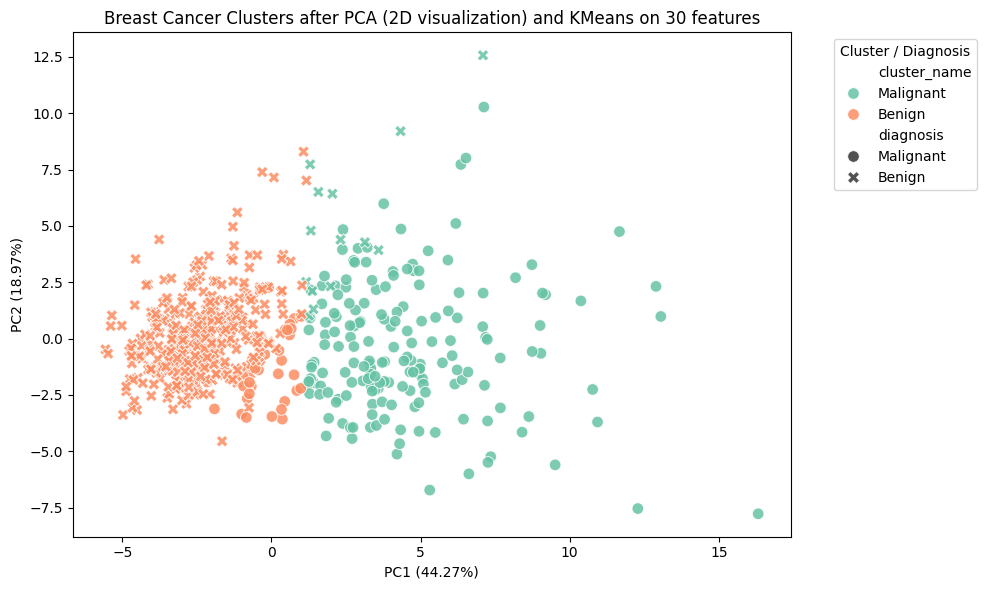

In [17]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, silhouette_score

# Reduce the 30 standardized features to exactly 2 principal components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=data.index)
pca_df["diagnosis"] = data["diagnosis"].map({"M": "Malignant", "B": "Benign"})

print(f"PCA output shape: {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_[0]:.2%}, {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# Fit KMeans on the full standardized feature space instead of only the 2 PCA dimensions
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
pca_df["cluster"] = kmeans.fit_predict(X_scaled)
pca_df["cluster_name"] = pca_df.groupby("cluster")["diagnosis"].transform(lambda values: values.mode().iloc[0])

# Inspect how the highlighted features contribute to the first two PCA components
important_features = [
    "concave points_worst",
    "perimeter_worst",
    "radius_worst",
    "area_worst",
    "concavity_worst",
]
loading_df = pd.DataFrame(pca.components_.T, index=feature_columns, columns=["PC1", "PC2"])
print("\nPCA loadings for the highlighted features:")
print(loading_df.loc[important_features].sort_values("PC1", ascending=False))

# Compare the cluster assignments with the diagnosis labels
print("\nCluster vs diagnosis cross-tab:")
print(pd.crosstab(pca_df["cluster"], pca_df["diagnosis"]))
print("\nSilhouette score on the full standardized feature space:")
print(f"{silhouette_score(X_scaled, pca_df['cluster']):.4f}")
print("\nClassification report after majority-vote cluster mapping:")
print(classification_report(pca_df["diagnosis"], pca_df["cluster_name"]))

# Visualize the 2D PCA space with KMeans clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster_name",
    style="diagnosis",
    palette="Set2",
    s=70,
    alpha=0.85,
)
plt.title("Breast Cancer Clusters after PCA (2D visualization) and KMeans on 30 features")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
plt.legend(title="Cluster / Diagnosis", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()